# Formelsamling — SW2PLA
Komplet oversigt over alle formler med forklaringer og kodeeksempler.

**Indhold:**
1. [Vektorer](#1) — norm, enhedsvektor, dot product, ortogonalitet, lin. uafhængighed
2. [Basistransformation](#2) — koordinatskift, visualisering
3. [Matricer](#3) — oprettelse, typer, trace, determinant, invers, norm, **ortogonal matrix**
4. [Rang & nullrum](#4) — rang, nullrum, rang-nullitets-sætning
5. [Transformationsmatricer](#5) — rotation, translation, skalering
6. [Ligningssystemer](#6) — solve, RREF
7. [LU-dekomposition](#7)
8. [QR-dekomposition](#8)
9. [Mindste kvadrater / GLM](#9) — SSE, R²
10. [Egendekomposition](#10) — diagonalisering
11. [SVD](#11) — rekonstruktion, relation til egendekomposition
12. [Low-rank approksimation](#12)
13. [PCA](#13)
14. [GED / LDA](#14) — covB, covW

In [2]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt


---
## 1. Vektorer <a id='1'></a>

### 1.1 Norm af en vektor
- Normen af en vektor er et matematisk mål for dens **længde** eller "størrelse" i rummet.
- Kort sagt fortæller normen dig, hvor "kraftfuldt" eller "langt væk" et punkt er fra origo.
- Den mest brugte er L2-normen (euklidisk), som svarer til den direkte afstand i rummet.

Normen (L2/euklidisk) måler vektorens længde:

$$\|v\|_2 = \sqrt{\sum_{i=1}^n v_i^2}$$

In [3]:
v = np.array([4, 3])

# Med numpy
norm_v = np.linalg.norm(v)
print("Norm af v (numpy):", norm_v)

# Manuel beregning (uden builtin)
norm_v_manuel = np.sqrt(np.sum(v**2))
print("Norm af v (manuel):", norm_v_manuel)


Norm af v (numpy): 5.0
Norm af v (manuel): 5.0


### 1.2 Enhedsvektor
- Enhedsvektorer bruges til at beskrive, **hvilken retning** en vektor peger, uden at tage højde for dens størrelse.
- Man kan forestille sig en pil: enhedsvektoren er pilen med præcis 1 enheds længde, der peger i samme retning.
- Bruges bl.a. til at normalisere data og sammenligne retninger uafhængigt af størrelse.

Peger i samme retning som $v$, men har længde 1:

$$\hat{v} = \frac{v}{\|v\|}$$

In [4]:
unit_v = v / norm_v
print("Enhedsvektor:", unit_v)
print("Verifikation — norm skal være 1:", np.linalg.norm(unit_v))


Enhedsvektor: [0.8 0.6]
Verifikation — norm skal være 1: 1.0


### 1.3 Dot product og ortogonalitet
- Dot produktet måler, **hvor meget to vektorer peger i samme retning**.
- Et positivt resultat → vektorerne peger i samme retning. Negativt → modsatte retninger. Nul → **vinkelrette** (ortogonale).
- Geometrisk er dot produktet lig $\|v\| \cdot \|w\| \cdot \cos(\theta)$, hvor $\theta$ er vinklen imellem dem.

$$v \cdot w = \sum_{i=1}^n v_i w_i$$

Hvis $v \cdot w = 0$ er vektorerne **ortogonale** (vinkelrette på hinanden).

In [5]:
v = np.array([4, 3])
w = np.array([5, 2])

dot_vw = np.dot(v, w)
print("Dot product v · w:", dot_vw)

# Tjek ortogonalitet
v1 = np.array([7, 0, 0])
v2 = np.array([0, 1, 2])
print("\nv1 · v2 =", np.dot(v1, v2), "→ ortogonale:", np.dot(v1, v2) == 0)


Dot product v · w: 26

v1 · v2 = 0 → ortogonale: True


### 1.4 Lineær uafhængighed via determinant
- Vektorer er **lineært uafhængige** hvis ingen af dem kan skrives som en kombination af de andre.
- Praktisk set: de peger i "virkelig forskellige" retninger og spænder rummet fuldt ud.
- Hvis determinanten ≠ 0, er søjlerne uafhængige — matricen er invertibel og ligningssystemet har en unik løsning.

Vektorer er **lineært uafhængige** hvis $\det(A) \neq 0$.

In [6]:
v1 = np.array([1, 2])
v2 = np.array([3, 4])
A = np.column_stack([v1, v2])

det = np.linalg.det(A)
print("Determinant:", round(det, 6))
print("Lineært uafhængige:", abs(det) > 1e-10)


Determinant: -2.0
Lineært uafhængige: True


### 1.5 Visualisering af vektorer
- Vektorer kan visualiseres enten som **pile** (viser retning og størrelse fra et startpunkt) eller som **punkter** (viser blot vektorens slutposition).
- `plt.quiver` tegner pile fra et startpunkt i en given retning — godt til at vise transformation eller retning.
- `plt.scatter` tegner vektorernes slutpunkter som punkter — godt til at vise fordelinger i rummet.

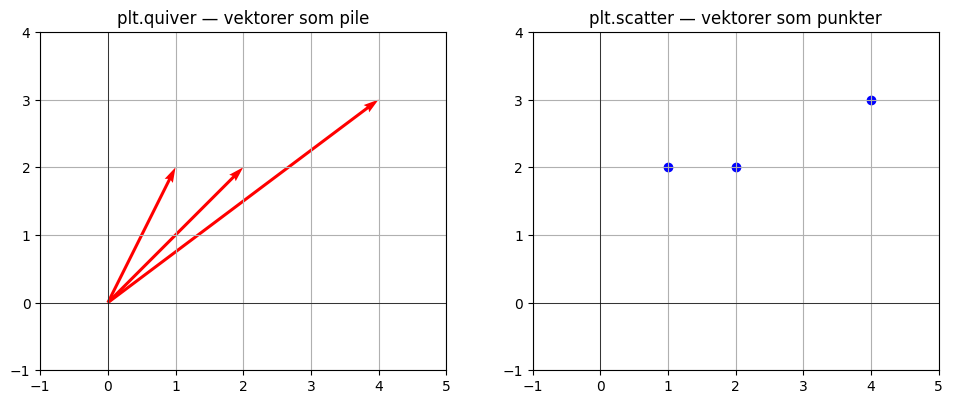

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Vektorer som pile (quiver)
vectors = np.array([[1, 2], [2, 2], [4, 3]])
origin  = np.zeros_like(vectors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Pile
ax1.set_title("plt.quiver — vektorer som pile")
ax1.quiver(origin[:,0], origin[:,1], vectors[:,0], vectors[:,1],
           angles='xy', scale_units='xy', scale=1, color='red')
ax1.set_xlim(-1, 5); ax1.set_ylim(-1, 4)
ax1.axhline(0, color='k', linewidth=0.5); ax1.axvline(0, color='k', linewidth=0.5)
ax1.grid(True); ax1.set_aspect('equal')

# Punkter
ax2.set_title("plt.scatter — vektorer som punkter")
ax2.scatter(vectors[:,0], vectors[:,1], color='blue')
ax2.set_xlim(-1, 5); ax2.set_ylim(-1, 4)
ax2.axhline(0, color='k', linewidth=0.5); ax2.axvline(0, color='k', linewidth=0.5)
ax2.grid(True); ax2.set_aspect('equal')

plt.tight_layout()
plt.show()


---
## 2. Basistransformation <a id='2'></a>

- En **basis** er et sæt af vektorer, der kan bruges til at beskrive alle punkter i et rum.
- En **basistransformation** konverterer koordinater fra én basis til en anden — som at skifte "koordinatsystem".
- Tænk på det som en oversættelse: samme punkt i rummet, bare beskrevet med en anden referenceramme.
- Bruges bl.a. i computer graphics, signalbehandling og maskinlæring.

Givet koordinater $c$ i basis $B$, find koordinater $d$ i basis $F$:

$$d = F^{-1} B c$$

Eller direkte: løs $F \cdot d = B \cdot c$ med `np.linalg.solve`.

In [8]:
# Basis B (kolonner er basisvektorer)
B = np.array([[1,  1,  1,  1],
              [1,  1, -1,  1],
              [1, -1,  1,  1],
              [1,  1,  1, -1]], dtype=float)

# Basis F
F = np.array([[ 1, -1,  4, -2],
              [-14, 2, -2,  8],
              [ 23, 7,  1, -1],
              [ 1,  1,  2,  5]], dtype=float)

# Koordinater i basis B
c_B = np.array([3, 5, 8, -1], dtype=float)

# Koordinater i standard basis: v_std = B @ c_B
v_std = B @ c_B
print("Koordinater i standardbasis:", v_std)

# Koordinater i basis F: løs F @ c_F = v_std
c_F = np.linalg.solve(F, v_std)
print("Koordinater i basis F:", np.round(c_F, 6))

# Verifikation: F @ c_F skal give v_std
print("Verifikation F @ c_F:", np.round(F @ c_F, 6))


Koordinater i standardbasis: [15. -1.  5. 17.]
Koordinater i basis F: [ 0.339134 -0.771222  4.34635   1.747878]
Verifikation F @ c_F: [15. -1.  5. 17.]


---
## 3. Matricer <a id='3'></a>

### 3.1 Matrixtyper
- **Diagonalmatrix:** Alle ikke-diagonale elementer er nul. Meget nem at invertere og multiplicere — kun diagonalen er vigtig.
- **Symmetrisk matrix:** $A = A^T$ — spejling om diagonalen ændrer intet. Garanterer reelle egenværdier (spektralsætningen).
- **Identitetsmatrix:** "Neutral element" for matrixmultiplikation — $AI = IA = A$. Svarer til tallet 1 for matricer.
- **Nulmatrix:** Alle elementer er nul. Multiplicering giver altid nulmatrix uanset den anden matrix.

In [9]:
# Diagonalmatrix
D = np.array([[8,  0,  0],
              [0, 10,  0],
              [0,  0,  4]], dtype=float)
print("Diagonalmatrix D:"); print(D)

# Tjek: symmetrisk matrix (A == A.T)
A = np.array([[1, 2, 3],
              [2, 5, 6],
              [3, 6, 9]], dtype=float)
print("\nEr A symmetrisk?", np.allclose(A, A.T))

# Identitetsmatrix
I = np.eye(4)
print("\n4x4 Identitetsmatrix:"); print(I)

# Nulmatrix
Z = np.zeros((3, 3))
print("\n3x3 Nulmatrix:"); print(Z)


Diagonalmatrix D:
[[ 8.  0.  0.]
 [ 0. 10.  0.]
 [ 0.  0.  4.]]

Er A symmetrisk? True

4x4 Identitetsmatrix:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

3x3 Nulmatrix:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


### 3.2 Invers af diagonalmatrix
- For en diagonalmatrix er det ekstremt nemt at beregne inversionen — man **vender blot hvert diagonalelement om** ($d_i \to 1/d_i$).
- Det skyldes, at diagonalmatricens rækker allerede er ortogonale, så der ingen interaktion er mellem dem.
- Vigtigt: hvis et diagonalelement er 0, eksisterer inversionen ikke (matricen er singulær).

For en diagonalmatrix er inversens diagonalelementer $1/d_i$:

$$D^{-1} = \text{diag}\left(\frac{1}{d_1}, \frac{1}{d_2}, \ldots, \frac{1}{d_n}\right)$$

In [10]:
D = np.array([[8,  0,  0],
              [0, 10,  0],
              [0,  0,  4]], dtype=float)

D_inv = np.linalg.inv(D)
print("D_inv:"); print(np.round(D_inv, 6))
print("\nVerifikation D @ D_inv = I:"); print(np.round(D @ D_inv, 6))


D_inv:
[[0.125 0.    0.   ]
 [0.    0.1   0.   ]
 [0.    0.    0.25 ]]

Verifikation D @ D_inv = I:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### 3.3 Trace
- Sporet (trace) er summen af diagonalelementerne i en kvadratisk matrix.
- Det er en vigtig størrelse fordi det er **lig summen af alle egenværdier** — uden at man behøver at beregne dem.
- Bruges bl.a. til at beregne total varians i PCA og som et hurtigt mål for matrixens "samlede strækning".

$$\text{tr}(A) = \sum_{i=1}^n a_{ii}$$

In [11]:
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]], dtype=float)
print("Trace:", np.trace(A))


Trace: 15.0


### 3.4 Determinant
- Determinanten er et enkelt tal, der fortæller om en matrix er **invertibel** (kan "fortrydes") eller ej.
- Geometrisk: determinanten måler, hvor meget en matrix skalerer arealet (2D) eller volumenet (3D) i transformationen.
- En nul-determinant betyder, at transformationen "klemmer" rummet ned i færre dimensioner — information går tabt og matricen kan ikke inverteres.

$$\det(A) \neq 0 \iff A \text{ er invertibel} \iff \text{fuld rang} \iff \text{lin. uafh. søjler}$$

In [12]:
A = np.array([[2, 1, 0],
              [4, 3, 2],
              [1, 0, 5]], dtype=float)
det = np.linalg.det(A)
print("Determinant:", round(det, 6))
print("Invertibel:", abs(det) > 1e-10)


Determinant: 12.0
Invertibel: True


### 3.5 Matrix-invers
- Inversionen er en matrices "fortrydelsesoperation": $A \cdot A^{-1}$ giver identitetsmatricen $I$.
- Eksisterer **kun** når determinanten ≠ 0 (matricen har fuld rang og lineært uafhængige søjler).
- Bruges til at løse ligningssystemer: $Ax = b \Rightarrow x = A^{-1}b$ — men i praksis er `np.linalg.solve` mere numerisk stabil.

$$A \cdot A^{-1} = I$$

**Egenskaber:** $(A^{-1})^{-1} = A$, $(A^T)^{-1} = (A^{-1})^T$, $\det(A^{-1}) = 1/\det(A)$

In [13]:
A = np.array([[2, 1, 0],
              [4, 3, 2],
              [1, 0, 5]], dtype=float)

A_inv = np.linalg.inv(A)
print("A_inv:"); print(np.round(A_inv, 4))
print("\nVerifikation A @ A_inv = I:"); print(np.round(A @ A_inv, 6))


A_inv:
[[ 1.25   -0.4167  0.1667]
 [-1.5     0.8333 -0.3333]
 [-0.25    0.0833  0.1667]]

Verifikation A @ A_inv = I:
[[ 1. -0.  0.]
 [ 0.  1.  0.]
 [ 0.  0.  1.]]


### 3.6 Matrix norm (Frobenius)
- Frobenius-normen udvider tanken om vektorlængde til matricer — den måler den samlede "størrelse" af alle elementer på én gang.
- Matematisk er det roden af summen af kvadraterne på alle elementer, præcis som L2-normen for vektorer.
- Bruges bl.a. til at måle fejlen i en low-rank approksimation og til at sammenligne matricer.

$$\|A\|_F = \sqrt{\sum_{i,j} a_{ij}^2}$$

In [14]:
A = np.array([[1, 2], [3, 4]], dtype=float)

# Med numpy (Frobenius er default)
norm_A = np.linalg.norm(A)
print("Frobenius norm (numpy):", norm_A)

# Manuel beregning
norm_A_manuel = np.sqrt(np.sum(A**2))
print("Frobenius norm (manuel):", norm_A_manuel)


Frobenius norm (numpy): 5.477225575051661
Frobenius norm (manuel): 5.477225575051661


### 3.7 Ortogonal matrix

- En ortogonal matrix er en kvadratisk matrix, hvor **søjlerne (og rækkerne) udgør et ortonormalt sæt** — de er parvis vinkelrette og har alle længde 1.
- Geometrisk repræsenterer en ortogonal matrix en **ren rotation eller spejling** — den ændrer ikke afstande eller vinkler.
- Ortogonale matricer er altid invertible og numerisk meget stabile.

---

#### Korrekt ortogonalitets-statement

En matrix $Q \in \mathbb{R}^{n \times n}$ er ortogonal **hvis og kun hvis** én (og dermed alle) af disse ækvivalente betingelser holder:

| Betingelse | Hvad det siger |
|---|---|
| $Q^T Q = I$ | Søjlerne er ortonormale (standard tjek) |
| $Q Q^T = I$ | Rækkerne er ortonormale |
| $Q^{-1} = Q^T$ | Inversionen er gratis — transponer blot |
| $\|Qv\|_2 = \|v\|_2$ for alle $v$ | Bevarer **længder** (isometri) |
| $(Qu) \cdot (Qv) = u \cdot v$ for alle $u, v$ | Bevarer **vinkler** og dot produkter |
| $|\det(Q)| = 1$ | Bevarer **volumen** (nødvendig, men ikke tilstrækkelig alene) |

> **Exam-tip:** Det hurtigste tjek er altid $Q^T Q = I$. Hvis det holder, er alle andre betingelser automatisk opfyldt.

In [15]:
# En simpel rotationsmatrix er ortogonal
angle = np.radians(45)
Q = np.array([[ np.cos(angle), -np.sin(angle)],
              [ np.sin(angle),  np.cos(angle)]])

print("Q (rotation 45°):")
print(np.round(Q, 4))

# Tjek Q^T Q = I
print("\nTjek Q.T @ Q = I:")
print(np.round(Q.T @ Q, 6))

# Tjek Q^{-1} = Q^T
print("\nTjek Q_inv == Q.T:", np.allclose(np.linalg.inv(Q), Q.T))

# Tjek |det(Q)| = 1
print("Tjek |det(Q)| = 1:", round(abs(np.linalg.det(Q)), 6))

# Tjek at Q bevarer vektorlængder
v = np.array([3.0, 4.0])
Qv = Q @ v
print(f"\nOprindelig norm ||v|| = {np.linalg.norm(v):.4f}")
print(f"Transformeret norm ||Qv|| = {np.linalg.norm(Qv):.4f}")
print("Bevarer længde:", np.isclose(np.linalg.norm(v), np.linalg.norm(Qv)))

# Tjek at Q bevarer vinkler (dot product)
u = np.array([1.0, 0.0])
v = np.array([0.0, 1.0])
print(f"\nu · v = {np.dot(u, v)}")
print(f"Qu · Qv = {np.dot(Q @ u, Q @ v):.6f}")
print("Bevarer vinkel:", np.isclose(np.dot(u, v), np.dot(Q @ u, Q @ v)))

Q (rotation 45°):
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Tjek Q.T @ Q = I:
[[ 1. -0.]
 [-0.  1.]]

Tjek Q_inv == Q.T: True
Tjek |det(Q)| = 1: 1.0

Oprindelig norm ||v|| = 5.0000
Transformeret norm ||Qv|| = 5.0000
Bevarer længde: True

u · v = 0.0
Qu · Qv = 0.000000
Bevarer vinkel: True


---
## 4. Rang & nullrum <a id='4'></a>

- **Rangen** er antallet af lineært uafhængige søjler (eller rækker) — altså dimensionen af søjlerummet. Fortæller, hvor "meget rum" matricen faktisk spænder.
- **Nullrummet** er mængden af alle vektorer $v$, der løser $Av = 0$ — de "forsvinder" under transformationen.
- En fuld-rang matrix har rang = antal søjler, og nullrummet består kun af nulvektoren.
- Rang-nullitets-sætningen viser, at rang og nullrum altid "balancerer" til det totale antal søjler:

$$\text{antal søjler} = \text{rank}(A) + \dim(\text{nullspace}(A))$$

In [16]:
A = np.array([[1, 2, 2, -6],
              [3, 5, 3, -9],
              [5, 9, 6, -18]], dtype=float)

rank = np.linalg.matrix_rank(A)
nullity = A.shape[1] - rank

print("Rang:", rank)
print("Dim(nullspace) =", nullity)
print("Fuld rang:", rank == min(A.shape))

# Test om vektor tilhører nullrummet (Av = 0?)
v = np.array([1, -2, 1, 0], dtype=float)
Av = A @ v
print("\nAv =", np.round(Av, 10))
print("v tilhører nullspace:", np.allclose(Av, 0))


Rang: 3
Dim(nullspace) = 1
Fuld rang: True

Av = [-1. -4. -7.]
v tilhører nullspace: False


---
## 5. Transformationsmatricer (computer graphics) <a id='5'></a>

I **homogene koordinater** repræsenteres et 2D punkt $(x, y)$ som $(x, y, 1)$.
Dette gør det muligt at kombinere rotation, skalering og translation med matrixmultiplikation.

$$P_{ny} = P \cdot T \quad \text{(translation)} \qquad P_{ny} = P \cdot R(v) \quad \text{(rotation)}$$


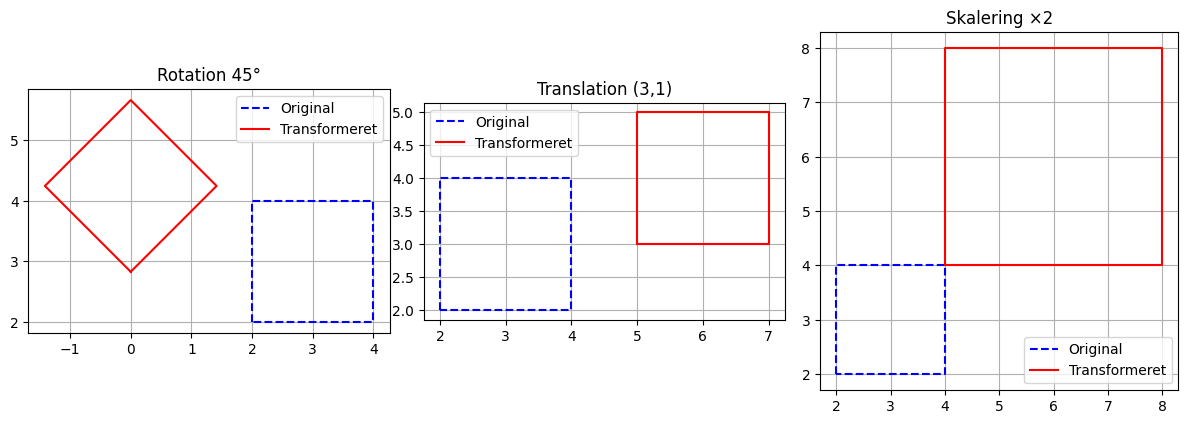

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Definer et kvadrat (homogene koordinater: [x, y, 1])
square = np.array([[2, 2, 1],
                   [2, 4, 1],
                   [4, 4, 1],
                   [4, 2, 1],
                   [2, 2, 1]], dtype=float)  # lukket polygon

# --- Rotationsmatrix (45 grader) ---
angle = np.radians(45)
R = np.array([[ np.cos(angle), np.sin(angle), 0],
              [-np.sin(angle), np.cos(angle), 0],
              [             0,             0, 1]])

# --- Translationsmatrix (flyt 3 til højre, 1 op) ---
T = np.array([[1, 0, 0],
              [0, 1, 0],
              [3, 1, 1]])

# --- Scalingsmatrix (dobbelt størrelse) ---
S = np.array([[2, 0, 0],
              [0, 2, 0],
              [0, 0, 1]])

rotated    = square @ R
translated = square @ T
scaled     = square @ S

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, pts, title in zip(axes,
                           [rotated, translated, scaled],
                           ["Rotation 45°", "Translation (3,1)", "Skalering ×2"]):
    ax.plot(square[:,0],  square[:,1],  'b--', label='Original')
    ax.plot(pts[:,0],     pts[:,1],     'r-',  label='Transformeret')
    ax.set_title(title); ax.legend(); ax.grid(True); ax.set_aspect('equal')
plt.tight_layout()
plt.show()


---
## 6. Løsning af lineære ligningssystemer <a id='6'></a>

### 6.1 np.linalg.solve — unik løsning
- Bruges når ligningssystemet $Ax = b$ har **præcis én løsning** — dvs. $A$ er kvadratisk og invertibel ($\det(A) \neq 0$).
- Mere numerisk stabil end at beregne $x = A^{-1}b$ direkte — undgår at akkumulere afrundingsfejl.
- Kaster en fejl hvis $A$ er singulær (dvs. der ingen unik løsning er).

Kræver kvadratisk $A$ med $\det(A) \neq 0$.

In [18]:
A = np.array([[ 2,  2],
              [-1,  2]], dtype=float)
b = np.array([8, 4], dtype=float)

x = np.linalg.solve(A, b)
print(f"x = {x[0]}, y = {x[1]}")
print("Verifikation A @ x =", A @ x, "(skal være", b, ")")


x = 1.3333333333333335, y = 2.6666666666666665
Verifikation A @ x = [8. 4.] (skal være [8. 4.] )


### 6.2 RREF — analyse af løsninger
- $\text{rank}([A|b]) = \text{rank}(A)$ → løsning eksisterer
- $\text{rank}(A) = n$ → **unik løsning**
- $\text{rank}(A) < n$ → **uendeligt mange løsninger**
- $\text{rank}([A|b]) > \text{rank}(A)$ → **ingen løsning**


In [19]:
from sympy import Matrix

A = np.array([[1,  2,  2],
              [2, -1, -1],
              [6, -3, -3]], dtype=float)
b = np.array([[5], [0], [0]], dtype=float)

Ab = np.hstack([A, b])
rref, pivot_cols = Matrix(Ab).rref()
print("RREF af [A|b]:")
print(rref)
print("\nPivot kolonner:", pivot_cols)
print("Rang A:", np.linalg.matrix_rank(A))
print("Rang [A|b]:", np.linalg.matrix_rank(Ab))


ModuleNotFoundError: No module named 'sympy'

---
## 7. LU-dekomposition <a id='7'></a>

- LU nedbryder en matrix i tre faktorer: en permutationsmatrix $P$, en nedre trekantmatrix $L$ og en øvre trekantmatrix $U$.
- $P$ ombytter rækker for numerisk stabilitet. $L$ og $U$ gør det nemt at løse ligningssystemer ved **forward/back substitution** i stedet for direkte inversion.
- Meget brugt "bag kulisserne" i `np.linalg.solve` og determinantberegning.

$$A = PLU$$

- $P$ = permutationsmatrix ($P \cdot P^T = I$ → $P$ er **ortogonal**)
- $L$ = nedre triangulær (lower)
- $U$ = øvre triangulær (upper)

In [ ]:
import scipy.linalg

A = np.array([[1, 2, 3],
              [0, 1, 4],
              [2, 4, 10]], dtype=float)

P, L, U = scipy.linalg.lu(A)

print("P:"); print(P)
print("\nL:"); print(np.round(L, 4))
print("\nU:"); print(np.round(U, 4))
print("\nVerifikation P @ L @ U ≈ A:"); print(np.round(P @ L @ U, 6))

# P er ortogonal: P @ P.T = I
print("\nP @ P.T = I:", np.allclose(P @ P.T, np.eye(len(P))))


---
## 8. QR-dekomposition <a id='8'></a>

- QR nedbryder en matrix i $Q$ (ortogonal) og $R$ (øvre trekant).
- $Q$ repræsenterer en ren rotation/spejling — den **bevarer vinkler og afstande** og er altid invertibel.
- Bruges til at løse mindste kvadraters problemer og er mere numerisk stabil end normalligningen $(X^TX)^{-1}X^Ty$.

$$A = QR$$

**Ortogonal matrix $Q$:**
- $Q^T Q = I$
- $Q^{-1} = Q^T$
- $\det(Q) = \pm 1$
- Repræsenterer en rotation

In [ ]:
A = np.array([[1, 2, 3],
              [0, 1, 4],
              [5, 6, 0]], dtype=float)

Q, R = np.linalg.qr(A)

print("Q:"); print(np.round(Q, 4))
print("\nR:"); print(np.round(R, 4))
print("\nTjek Q er ortogonal — Q.T @ Q = I:"); print(np.round(Q.T @ Q, 6))
print("\ndet(Q) =", round(np.linalg.det(Q), 6), "(skal være ±1)")
print("\nVerifikation Q @ R ≈ A:"); print(np.round(Q @ R, 6))


---
## 9. GLM og Mindste Kvadrater <a id='9'></a>

- Mindste kvadraters metode finder den **bedst mulige rette linje** (eller hyperplan) gennem datapunkterne — den, der minimerer summen af kvadrerede fejl (SSE).
- Bruges når vi vil finde en lineær sammenhæng i data, selvom der er støj eller variation.
- $R^2$ fortæller, hvor stor en andel af variansen i $y$ der forklares af modellen: 1.0 = perfekt fit, 0 = modellen forklarer ingenting.

**Model:** $y = \beta_1 x + \beta_0$

**De 4 trin i GLM-opsætning:**
1. Definer ligningen: $y = X\beta$
2. Kortlæg data til ligninger (designmatrix $X$)
3. Transformér til matrixligning
4. Løs: $\beta = (X^T X)^{-1} X^T y$

$$\text{SSE} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 \qquad R^2 = 1 - \frac{\text{SSE}}{\sum(y_i - \bar{y})^2}$$

In [20]:
# Data: studietimer vs. eksamenskarakter
hours  = np.array([3, 5, 6, 8, 9, 4, 7], dtype=float)
scores = np.array([55, 70, 75, 88, 90, 62, 82], dtype=float)

# Trin 1-3: Designmatrix [x, 1]
X = np.column_stack([hours, np.ones(len(hours))])

# Trin 4: Løs med mindste kvadrater
beta, _, _, _ = np.linalg.lstsq(X, scores, rcond=None)
beta1, beta0 = beta
print(f"Model: y = {beta1:.4f}x + {beta0:.4f}")

# Forudsigelse
x_new = 6.5
y_pred = beta1 * x_new + beta0
print(f"Forudsagt score for {x_new} timer: {y_pred:.2f}")

# SSE og R²
y_hat = X @ beta
SSE = np.sum((scores - y_hat)**2)
SS_tot = np.sum((scores - np.mean(scores))**2)
R2 = 1 - SSE / SS_tot
print(f"SSE: {SSE:.4f}")
print(f"R²:  {R2:.4f}  (1.0 = perfekt fit)")


Model: y = 6.0357x + 38.3571
Forudsagt score for 6.5 timer: 77.59
SSE: 15.6786
R²:  0.9849  (1.0 = perfekt fit)


### 9.2 Multi-variabel GLM
- Udvidelse af simple lineære modeller til **flere prædiktorer** — samme fremgangsmåde, bare med flere kolonner i designmatricen $X$.
- Giver mulighed for at modellere komplekse sammenhænge, f.eks. at forudsige en karakter ud fra både studietime og søvntimer.
- Koefficienten $\beta_i$ fortæller, hvor meget $y$ ændrer sig pr. enhed af $x_i$, når alle andre prædiktorer holdes konstante.

Model med flere prædiktorer: $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2$

In [ ]:
# Data: 2 prædiktorer (x1, x2) → y
x1 = np.array([1, 2, 3, 4, 5], dtype=float)  # f.eks. studietime
x2 = np.array([2, 1, 4, 3, 5], dtype=float)  # f.eks. søvntimer
y  = np.array([3, 4, 7, 6, 10], dtype=float)

# Designmatrix: [x1, x2, 1]
X = np.column_stack([x1, x2, np.ones(len(x1))])

beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
print(f"Model: y = {beta[0]:.4f}·x1 + {beta[1]:.4f}·x2 + {beta[2]:.4f}")

y_hat = X @ beta
SSE = np.sum((y - y_hat)**2)
print(f"SSE: {SSE:.4f}")


---
## 10. Egendekomposition (Diagonalisering) <a id='10'></a>

- En **egenvektor** er en retning, som matricen $A$ kun strækker (eller spejler) — ikke drejer.
- Den tilhørende **egenværdi** $\lambda$ fortæller, **hvor meget** den retning strækkes: $\lambda > 1$ forstørrer, $0 < \lambda < 1$ skrumper, $\lambda < 0$ spejler.
- Egendekomposition afslører matrixens "naturlige akser" og er grundlaget for PCA, SVD og GED.

$$Av = \lambda v \qquad A = V\Lambda V^{-1}$$

**Spektralsætningen:** Symmetrisk $A$ → reelle $\lambda$, ortogonale egenvektorer → $A = Q\Lambda Q^T$

In [ ]:
B = np.array([[4,  0,  0],
              [1,  2,  0],
              [-3, 0,  3]], dtype=float)

eigenvalues, V = np.linalg.eig(B)
D   = np.diag(eigenvalues)
V_inv = np.linalg.inv(V)

print("Egenværdier:", np.round(eigenvalues, 4))
print("\nV (egenvektorer som søjler):"); print(np.round(V, 4))
print("\nD (diagonal med egenværdier):"); print(np.round(D, 4))

# Rekonstruktion
B_rec = V @ D @ V_inv
print("\nVerifikation V @ D @ V_inv ≈ B:"); print(np.round(B_rec, 6))


---
## 11. SVD — Singular Value Decomposition <a id='11'></a>

- SVD er den mest generelle dekomposition — den virker på **alle** matricer, ikke kun kvadratiske.
- $U$ og $V^T$ er rotationer; $\Sigma$ indeholder singulærværdierne, der **rangordner hvor meget information** hvert "lag" i matricen bidrager med.
- Store singulærværdier = vigtige lag med meget information. Små singulærværdier = støj eller redundant information.
- Bruges til low-rank approksimation, PCA, pseudoinvers og billedkomprimering.

$$A = U \Sigma V^T$$

**Relation til egendekomposition:**
- $A^T A = V\Sigma^2 V^T$ → egenværdier af $A^TA$ = $\sigma_i^2$
- $AA^T = U\Sigma^2 U^T$ → egenværdier af $AA^T$ = $\sigma_i^2$

In [ ]:
B = np.array([[4,  0,  0],
              [1,  2,  0],
              [-3, 0,  3]], dtype=float)

U, S, Vt = np.linalg.svd(B)

print("U:"); print(np.round(U, 4))
print("\nS (singulærværdier):", np.round(S, 4))
print("\nVt:"); print(np.round(Vt, 4))

# Rekonstruktion
Sigma = np.zeros_like(B)
np.fill_diagonal(Sigma, S)
B_rec = U @ Sigma @ Vt
print("\nVerifikation U @ Sigma @ Vt ≈ B:"); print(np.round(B_rec, 6))

# Verifikation: S² = egenværdier af B.T @ B
evals_AtA = np.linalg.eigvalsh(B.T @ B)
evals_AtA_sorted = np.sort(evals_AtA)[::-1]
print("\nS²:", np.round(S**2, 4))
print("Egenværdier af BᵀB:", np.round(evals_AtA_sorted, 4))
print("Er ens:", np.allclose(np.sort(S**2)[::-1], evals_AtA_sorted))


---
## 12. Low-rank approksimation <a id='12'></a>

- En matrix kan opfattes som en sum af simple "lag" (rank-1 matricer), sorteret efter vigtighed via singulærværdierne.
- Ved at beholde kun de $k$ vigtigste lag bevarer man størstedelen af informationen — men med langt færre tal (komprimering).
- Jo større en singulærværdi $\sigma_i$ er, jo mere information bidrager det lag med. De mindste kan kastes væk som "støj".
- Bruges i billedkomprimering, anbefalingssystemer og støjfiltrering.

$$A = \sum_{i=1}^{r} \sigma_i \, u_i v_i^T \qquad \hat{A}_k = \sum_{i=1}^{k} \sigma_i \, u_i v_i^T, \quad k < r$$

De $k$ største singulærværdier bevarer størstedelen af informationen.

In [ ]:
B = np.array([[4,  0,  0],
              [1,  2,  0],
              [-3, 0,  3]], dtype=float)

U, S, Vt = np.linalg.svd(B)

# Fuld rekonstruktion
B_full = sum(S[i] * np.outer(U[:,i], Vt[i,:]) for i in range(len(S)))
print("Fuld rekonstruktion (alle lag):"); print(np.round(B_full, 4))

# Low-rank k=2
k = 2
B_approx = sum(S[i] * np.outer(U[:,i], Vt[i,:]) for i in range(k))
print(f"\nLow-rank approksimation (k={k}):"); print(np.round(B_approx, 4))
print(f"Fejl (Frobenius): {np.linalg.norm(B - B_approx):.4f}")


---
## 13. PCA — Principal Component Analysis <a id='13'></a>

- PCA finder de retninger i data, der indeholder **mest variation** — de såkaldte principalkomponenter.
- Bruges til **dimensionsreduktion**: man beholder de vigtigste komponenter og smider støjfyldte eller redundante retninger væk.
- Tænk på det som at finde det bedste "udsigtstårn" at se data fra, så man ser den størst mulige spredning i ét blik.
- Den forklarede varians fortæller, hvor meget information der bevares ved at beholde $k$ komponenter.

**De 5 trin:**
1. Mean-center: $X \leftarrow X - \bar{X}$
2. Kovariansmatrix: $C = \frac{X^T X}{n-1}$
3. Egendekomposition af $C$
4. Sortér efter faldende egenværdier
5. Projicér: components $= X \cdot V_k$

**Forklaret varians:** $\frac{\lambda_i}{\sum \lambda_j} \times 100\%$

In [21]:
np.random.seed(42)
X_raw = np.random.randn(100, 3)
X_raw[:, 1] += X_raw[:, 0]  # korrelation

# Trin 1: Mean-center
X = X_raw - np.mean(X_raw, axis=0, keepdims=True)

# Trin 2: Kovariansmatrix
C = X.T @ X / (X.shape[0] - 1)

# Trin 3: Egendekomposition
evals, evecs = np.linalg.eigh(C)

# Trin 4: Sortér faldende
idx   = np.argsort(evals)[::-1]
evals = evals[idx]
evecs = evecs[:, idx]

# Trin 5: Projicér (2 komponenter)
components = X @ evecs[:, :2]
print("Shape af projicerede data:", components.shape)

# Forklaret varians
var_exp = evals / np.sum(evals) * 100
for i, v in enumerate(var_exp):
    print(f"PC{i+1}: {v:.1f}%")

# Verifikation: varians af komponent = egenværdi
print("\nVarians PC1:", round(np.var(components[:,0], ddof=1), 6))
print("Egenværdi 1: ", round(evals[0], 6))

# Verifikation: korrelation mellem komponenter = 0
print("Korrelation PC1/PC2:", round(np.corrcoef(components[:,0], components[:,1])[0,1], 6))


Shape af projicerede data: (100, 2)
PC1: 57.3%
PC2: 32.9%
PC3: 9.8%

Varians PC1: 1.993698
Egenværdi 1:  1.993698
Korrelation PC1/PC2: -0.0


---
## 14. GED / LDA — Generalized Eigendecomposition <a id='14'></a>

- GED bruges til at finde den retning, der **bedst separerer to klasser** i data.
- I modsætning til PCA (som finder retninger med mest variation i alt), fokuserer GED på retninger, der maksimerer forskellen *mellem* klasser og minimerer spredningen *inden i* klasser.
- Tænk på det som: "Find den akse, der gør det nemmest at skelne gruppe A fra gruppe B."
- Bruges i klassifikation og mønstergenkendelse (Linear Discriminant Analysis, LDA).

$$S_w^{-1} S_b v = \lambda v$$

- $S_b$ = **covB** (between-class kovarians — variation *mellem* klasser)
- $S_w$ = **covW** (within-class kovarians — variation *inden i* klasser)

In [ ]:
np.random.seed(0)
N = 200

# To klasser af datapunkter
class1 = np.random.randn(N, 2)
class1[:, 1] += class1[:, 0]
class1 += np.array([2, -1])

class2 = np.random.randn(N, 2)
class2[:, 1] += class2[:, 0]

# Between-class kovarians (covB)
mean1 = np.mean(class1, axis=0, keepdims=True)
mean2 = np.mean(class2, axis=0, keepdims=True)
covB = (class1 - mean1).T @ (class1 - mean1) / N +        (class2 - mean2).T @ (class2 - mean2) / N

# Within-class kovarians (covW)
all_data = np.vstack([class1, class2])
mean_all = np.mean(all_data, axis=0, keepdims=True)
covW = (all_data - mean_all).T @ (all_data - mean_all) / (2*N)

print("covB (between-class kovarians):"); print(np.round(covB, 4))
print("\ncovW (within-class kovarians):"); print(np.round(covW, 4))

# GED: find egenværdier af covW^-1 @ covB
evals, evecs = scipy.linalg.eig(covB, covW)
evals = evals.real
evecs = evecs.real

# Sortér
idx   = np.argsort(evals)[::-1]
evals = evals[idx]
evecs = evecs[:, idx]

print("\nGED egenværdier:", np.round(evals, 4))
print("GED akse 1 (bedste separationsretning):", np.round(evecs[:, 0], 4))


---
## 🗂️ Hurtig oversigt — Python-funktioner

| Opgave | Kode |
|---|---|
| Norm af vektor | `np.linalg.norm(v)` |
| Manuel norm | `np.sqrt(np.sum(v**2))` |
| Enhedsvektor | `v / np.linalg.norm(v)` |
| Dot product | `np.dot(v, w)` |
| Matrixmultiplikation | `A @ B` |
| Transpose | `A.T` |
| Trace | `np.trace(A)` |
| Determinant | `np.linalg.det(A)` |
| Invers | `np.linalg.inv(A)` |
| Rang | `np.linalg.matrix_rank(A)` |
| Frobenius norm | `np.linalg.norm(A)` |
| Er symmetrisk? | `np.allclose(A, A.T)` |
| Er ortogonal? | `np.allclose(Q.T @ Q, np.eye(n))` |
| Løs Ax=b (kvadratisk) | `np.linalg.solve(A, b)` |
| Mindste kvadrater | `np.linalg.lstsq(X, y, rcond=None)` |
| RREF | `sympy.Matrix(Ab).rref()` |
| LU-dekomposition | `scipy.linalg.lu(A)` → P, L, U |
| QR-dekomposition | `np.linalg.qr(A)` → Q, R |
| Egendekomposition | `np.linalg.eig(A)` → værdier, vektorer |
| SVD | `np.linalg.svd(A)` → U, S, Vt |
| GED | `scipy.linalg.eig(covB, covW)` |
| Visualiser vektorer (pile) | `plt.quiver(ox, oy, vx, vy, angles='xy', scale_units='xy', scale=1)` |
| Visualiser vektorer (punkter) | `plt.scatter(x, y)` |


## Fagtermer
| Term | Beskrivelse |
|---|---|
| Norm af vektor | En norm af en vektor fortæller noget om længden af vectoren |
| Manuel norm | `np.sqrt(np.sum(v**2))` |
| Enhedsvektor | `v / np.linalg.norm(v)` |
| Dot product | `np.dot(v, w)` |
| Matrixmultiplikation | `A @ B` |
| Transpose | `A.T` |
| Trace | `np.trace(A)` |
| Determinant | `np.linalg.det(A)` |
| Invers | `np.linalg.inv(A)` |
| Rang | Rangen af en matrix fortæller dig, hvor meget "selvstændig information" matricen indeholder, og er defineret som det maksimale antal lineært uafhængige række- eller søjlevektorer. Hvis en matrix har **m** rækker og **n** søjler, og rangen er **r**, betyder det, at der præcis er r lineært uafhængige søjler og **r** lineært uafhængige rækker. Hvis du har en samling vektorer og indsætter dem som søjler i en matrix, er vektorerne lineært uafhængige, hvis og kun hvis **rangen** af matricen er **lig med antallet af søjler**. Er rangen mindre end antallet af søjler, er de lineært afhængige. Fuld rang (Full rank): Hvis en matrix har fuld rang, er alle dens søjler (og rækker) lineært uafhængige. Det betyder bl.a., at matricen kan inverteres, og at ligningssystemet \(Ax = 0\) kun har den trivielle løsning \(x = 0\).|
| Frobenius norm | `np.linalg.norm(A)` |
| Er symmetrisk? | `np.allclose(A, A.T)` |
| Er ortogonal? | `np.allclose(Q.T @ Q, np.eye(n))` |
| Løs Ax=b (kvadratisk) | `np.linalg.solve(A, b)` |
| Mindste kvadrater | `np.linalg.lstsq(X, y, rcond=None)` |
| RREF | `sympy.Matrix(Ab).rref()` |
| LU-dekomposition | `scipy.linalg.lu(A)` → P, L, U |
| QR-dekomposition | `np.linalg.qr(A)` → Q, R |
| Egendekomposition | `np.linalg.eig(A)` → værdier, vektorer |
| SVD | `np.linalg.svd(A)` → U, S, Vt |
| GED | `scipy.linalg.eig(covB, covW)` |
| Visualiser vektorer (pile) | `plt.quiver(ox, oy, vx, vy, angles='xy', scale_units='xy', scale=1)` |
| Visualiser vektorer (punkter) | `plt.scatter(x, y)` |
